# Retrospective Memory DDPM Analysis

This notebook implements a standalone, reproducible pipeline for analyzing retrospective memory representations in a DDPM model. Each section is clearly separated and documented for legibility and ease of use.


## 1. Setup: Environment, Imports, Constants

Install and import required libraries. Define constants and configuration variables for the analysis.

In [3]:
# Install required packages if missing (uncomment if needed)
# !pip install numpy matplotlib scikit-learn pandas pytest

import os
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from pathlib import Path
import colorsys
import pickle
import json
import torch
from purias_utils.multiitem_working_memory.util.circle_utils import polar2cart

# Get absolute paths
REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
DATA_DIR = REPO_ROOT / 'ddpm' / 'analysis' / 'new_analysis'

# Ensure repo root is importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Model and analysis parameters
PREP_IDX = 2  # Start of delay 1
NEURAL_DIM = 16  # Dimensionality of extracted neural state
N_TRIALS = 200  # Number of non-swap trials to generate
ANGLE_STEP = 30  # Angle step in degrees
SEED = 42
np.random.seed(SEED)

# Print to verify paths
print(f"Working directory: {os.getcwd()}")
print(f"Data directory: {DATA_DIR}")
print(f"sys.path includes repo root: {str(REPO_ROOT) in sys.path}")


Working directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis
Data directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis
sys.path includes repo root: True


In [4]:
NULLSPACE_JSON_PATH = None
TEACHER_ARGS_PATH = REPO_ROOT / "results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/args.yaml"
TEACHER_CKPT_PATH = REPO_ROOT / "results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/state.mdl"

# Healthy teacher default; no ablation direction is applied
ABLATION_DIRECTION_IDX = None
# Which student to analyse for the single-run default (0–13)
STUDENT_ID = 8

MODEL_RUN_CONFIGS = {
    "healthy_teacher": {
        "args_path": TEACHER_ARGS_PATH,
        "checkpoint_path": TEACHER_CKPT_PATH,
        "nullspace_json_path": NULLSPACE_JSON_PATH,
        "ablation_direction_idx": ABLATION_DIRECTION_IDX,
    },
    f"student_recovery_{STUDENT_ID}": {
        "args_path": REPO_ROOT / f"results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_{STUDENT_ID}/args.yaml",
        "checkpoint_path": REPO_ROOT / f"results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_{STUDENT_ID}/state.mdl",
        "nullspace_json_path": None,
        "ablation_direction_idx": None,
    },
}


In [5]:
import sys
from pathlib import Path

_REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from ddpm.utils.loading import generate_model_and_task_from_args_path_multiepoch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def _load_single_nullspace_vector(json_path, direction_idx, device):
    """Load one nullspace vector [D] by index from the JSON file."""
    with open(json_path) as f:
        data = json.load(f)
    vectors = data["nullspace_vectors"]["vectors"]
    sorted_keys = sorted(vectors.keys())
    key = sorted_keys[direction_idx]
    vec = np.array(vectors[key], dtype=np.float32)
    print(f"  ablation:   direction {direction_idx} ('{key}'), shape {vec.shape}")
    return torch.tensor(vec, device=device)


LOADED_MODELS = {}
EXTRACTED_RUN_DATA = {}
ANALYSIS_RUN_ORDER = list(MODEL_RUN_CONFIGS.keys())
DEFAULT_ACTIVE_RUN = ANALYSIS_RUN_ORDER[0]

for run_name, cfg in MODEL_RUN_CONFIGS.items():
    print("=" * 80)
    print(f"Loading run '{run_name}'")
    print(f"  args:       {cfg['args_path']}")
    print(f"  checkpoint: {cfg['checkpoint_path']}")
    _, task_r, model_r, _, _ = generate_model_and_task_from_args_path_multiepoch(
        str(cfg["args_path"]), device,
    )
    ckpt = torch.load(cfg["checkpoint_path"], map_location=device, weights_only=True)
    model_r.load_state_dict(ckpt)
    model_r.eval()
    ablation_vec = None
    if cfg["nullspace_json_path"] is not None:
        ablation_vec = _load_single_nullspace_vector(
            cfg["nullspace_json_path"], cfg["ablation_direction_idx"], device,
        )
    else:
        print(f"  ablation:   none")
    results_dir = DATA_DIR / "results" / "retrospective_memory_dual" / run_name
    results_dir.mkdir(parents=True, exist_ok=True)
    LOADED_MODELS[run_name] = {
        "model": model_r,
        "task": task_r,
        "ablation_matrix": ablation_vec,
        "results_dir": results_dir,
    }


task = model = ACTIVE_ABLATION_VECTOR = RESULTS_DIR = RUN_LABEL = None
neural_states = metadata = None


def activate_run(run_name, restore_extracted=True):
    global task, model, ACTIVE_ABLATION_VECTOR, RESULTS_DIR, RUN_LABEL, neural_states, metadata
    cfg = LOADED_MODELS[run_name]
    task = cfg["task"]
    model = cfg["model"]
    ACTIVE_ABLATION_VECTOR = cfg["ablation_matrix"]
    RESULTS_DIR = cfg["results_dir"]
    RUN_LABEL = run_name
    if restore_extracted and run_name in EXTRACTED_RUN_DATA:
        neural_states = EXTRACTED_RUN_DATA[run_name]["neural_states"]
        metadata = EXTRACTED_RUN_DATA[run_name]["metadata"]
    print(f"Active run: {run_name}")
    print(f"  Results directory: {RESULTS_DIR}")
    abl = ACTIVE_ABLATION_VECTOR
    if abl is not None:
        print(f"  Ablation: single direction, shape {tuple(abl.shape)}")
    else:
        print(f"  Ablation: none")


def extract_neural_state_from_model(trial, task, model, device, prep_idx=2, ablation_vector=None, neural_dim=16):
    with torch.no_grad():
        probe_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
        report_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
        override_stimulus_features = {
            'probe_features': probe_features,
            'report_features': report_features,
        }
        override_stimulus_cart_features = {
            f'{k}_cart': torch.stack(polar2cart(1.0, v), -1)
            for k, v in override_stimulus_features.items()
        }
        override_stimulus_features_dict = {
            **override_stimulus_features,
            **override_stimulus_cart_features,
            'cued_item_idx': torch.tensor([trial['cue'] - 1]),
        }
        task_variable_dict = task.task_variable_gen.generate_variable_dict(
            batch_size=1, override_stimulus_features_dict=override_stimulus_features_dict
        )
        trial_info = task.generate_trial_information(
            batch_size=1, num_samples=1, override_task_variable_information=task_variable_dict
        )
        prep_inputs = [inp.to(device) if isinstance(inp, torch.Tensor) else inp for inp in trial_info.prep_network_inputs]
        diff_inputs = [inp.to(device) if isinstance(inp, torch.Tensor) else inp for inp in trial_info.diffusion_network_inputs]
        sample_kwargs = {
            'prep_network_inputs': prep_inputs,
            'diffusion_network_inputs': diff_inputs,
            'prep_epoch_durations': trial_info.prep_epoch_durations,
            'diffusion_epoch_durations': trial_info.diffusion_epoch_durations,
            'samples_shape': [1, 1],
            'noise_scaler': 1.0,
        }
        if ablation_vector is not None:
            sample_kwargs['ablation_vector'] = ablation_vector
        prep_dicts, _ = model.generate_samples(**sample_kwargs)
        return prep_dicts[prep_idx]["postprep_state"][0, 0, :neural_dim].cpu().numpy()



Using device: cuda
Loading run 'healthy_teacher'
  args:       /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/args.yaml
  checkpoint: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/state.mdl
  ablation:   none
Loading run 'student_recovery_8'
  args:       /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_8/args.yaml
  checkpoint: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_8/state.mdl
  ablation:   none


In [6]:
# Cell: Section 3 - Trial Generation
"""
## 3. Generate Trial Combinations (Non-Swap Trials)

Generate all combinations of cue, color1, and color2 for analysis.
"""

def generate_trial_combinations(angle_step=30):
    """
    Generate all non-swap trial combinations.
    
    Args:
        angle_step: Step size for color angles in degrees
        
    Returns:
        List of trial dictionaries with cue, color1_angle, color2_angle
    """
    angles = list(range(0, 360, angle_step))
    trials = []
    
    for cue in [1, 2]:
        for color1 in angles:
            for color2 in angles:
                trials.append({
                    'cue': cue,
                    'color1_angle': color1,
                    'color2_angle': color2,
                    'swap': False
                })
    return trials

trials = generate_trial_combinations()

In [7]:
def extract_states_for_run(run_name, prep_idx=2, force=False):
    """Extract and store neural states for one configured run (always fresh extraction)."""
    activate_run(run_name, restore_extracted=False)
    print(f"Extracting neural states for run='{run_name}', prep_idx={prep_idx}...")
    print(f"Total trials to process: {len(trials)}")

    neural_states_run = []
    metadata_run = []

    for i, trial in enumerate(trials):
        if i % 50 == 0:
            print(f"  [{run_name}] trial {i}/{len(trials)}")
        state = extract_neural_state_from_model(
            trial,
            task,
            model,
            device,
            prep_idx=prep_idx,
            ablation_vector=ACTIVE_ABLATION_VECTOR,
        )
        neural_states_run.append(state)
        metadata_run.append([trial["cue"], trial["color1_angle"], trial["color2_angle"]])

    neural_states_run = np.asarray(neural_states_run, dtype=np.float32)
    metadata_run = np.asarray(metadata_run, dtype=np.float32)

    EXTRACTED_RUN_DATA[run_name] = {
        "prep_idx": prep_idx,
        "neural_states": neural_states_run,
        "metadata": metadata_run,
    }

    print(f"✓ [{run_name}] extracted {len(neural_states_run)} states with shape {neural_states_run.shape}")
    return neural_states_run, metadata_run


# Extract for both runs with fresh sampling
for _run_name in ANALYSIS_RUN_ORDER:
    extract_states_for_run(_run_name, prep_idx=PREP_IDX, force=True)

# Restore default active run and expose its arrays in notebook globals
activate_run(DEFAULT_ACTIVE_RUN, restore_extracted=True)
print("\nRun extraction complete.")
print("Use activate_run('teacher') or activate_run('student') before running analysis/plot cells.")
print(f"Current active run: {RUN_LABEL}")
print(f"Current states shape: {neural_states.shape}")

Active run: healthy_teacher
  Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher
  Ablation: none
Extracting neural states for run='healthy_teacher', prep_idx=2...
Total trials to process: 288
  [healthy_teacher] trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD

In [ ]:
def use_teacher():
    run_name = "healthy_teacher"
    activate_run(run_name, restore_extracted=True)


def use_student():
    run_name = f"student_recovery_{STUDENT_ID}"
    activate_run(run_name, restore_extracted=True)


print("Workflow for two full plot sets:")
print("  1) Run use_teacher(), then execute analysis/plot cells below.")
print("  2) Run use_student(), then execute the same analysis/plot cells again.")
print("Each run writes to its own RESULTS_DIR, so filenames do not collide.")


In [8]:
# ── Full analysis function (self-contained, runs for whatever is active) ─────

def run_full_analysis_for_active_run():
    """Run all analysis + save all plots for the currently active run.

    Reads globals: task, model, device, ACTIVE_ABLATION_VECTOR, RESULTS_DIR,
                   RUN_LABEL, neural_states, metadata, trials.
    """
    import colorsys as _col
    from matplotlib.lines import Line2D as _L2D
    from sklearn.decomposition import PCA as _PCA

    _NB = globals().get('N_BINS', 12)

    print(f"\n{'═'*72}\nFULL ANALYSIS: {RUN_LABEL}\n{'═'*72}")

    # ── local helpers ─────────────────────────────────────────────────────────

    def _hue(b, n=12):
        return _col.hsv_to_rgb(b / n, 0.9, 0.9)

    def _bangle(a, sz=30.0):
        return int(a // sz) % int(360 // sz)

    def _fit(data):
        ctr = data.mean(0)
        p = _PCA(n_components=3).fit(data - ctr)
        n = p.components_[2]; n /= np.linalg.norm(n)
        return n, ctr, float(p.explained_variance_ratio_[:2].sum()), p.explained_variance_ratio_

    def _angle_deg(n1, n2):
        return float(np.degrees(np.arccos(np.clip(abs(np.dot(n1, n2)), 0, 1))))

    def _bin_cued(states, meta, nb=12):
        sz = 360.0 / nb
        bd = {c: {b: [] for b in range(nb)} for c in [1, 2]}
        for i, (cue, c1, c2) in enumerate(meta):
            cue = int(cue)
            bd[cue][_bangle(c1 if cue == 1 else c2, sz)].append(states[i])
        av = {c: np.full((nb, states.shape[1]), np.nan) for c in [1, 2]}
        for c in [1, 2]:
            for b, sl in bd[c].items():
                if sl: av[c][b] = np.mean(sl, 0)
        return av

    def _avg_role(states_t, meta_a, cue, role, nb=12):
        sz = 360.0 / nb
        mask = meta_a[:, 0].astype(int) == cue
        st, mt = states_t[mask], meta_a[mask]
        bins = {b: [] for b in range(nb)}
        for s, (_, c1, c2) in zip(st, mt):
            a = (c1 if cue == 1 else c2) if role == 'target' else (c2 if cue == 1 else c1)
            bins[_bangle(a, sz)].append(s)
        out = [np.mean(bins[b], 0) for b in range(nb) if bins[b]]
        return np.array(out, np.float32) if out else np.empty((0, states_t.shape[1]), np.float32)

    def _pc12v(x):
        if x.shape[0] < 3: return np.nan
        p = _PCA(n_components=min(3, x.shape[0], x.shape[1])).fit(x)
        return float(p.explained_variance_ratio_[:2].sum())

    def _ts_metrics(st, ma, cue, nb=12):
        ta = _avg_role(st, ma, cue, 'target', nb)
        da = _avg_role(st, ma, cue, 'distractor', nb)
        nan = dict(plane_angle_deg=np.nan, planarity_cos=np.nan,
                   centroid_separation=np.nan, target_var_pc12=np.nan,
                   distractor_var_pc12=np.nan, combined_var_pc12=np.nan,
                   target_planarity=np.nan, distractor_planarity=np.nan,
                   target_centroid_norm=np.nan, distractor_centroid_norm=np.nan,
                   target_mean_radius=np.nan, target_radius_std=np.nan,
                   distractor_mean_radius=np.nan, distractor_radius_std=np.nan,
                   target_eccentricity=np.nan, distractor_eccentricity=np.nan,
                   target_arc_std=np.nan, distractor_arc_std=np.nan,
                   ring_separation_dprime=np.nan)
        if ta.shape[0] < 3 or da.shape[0] < 3: return nan
        comb = np.vstack([ta, da])
        pc = _PCA(n_components=3); coords = pc.fit_transform(comb)
        tn_v, tc, tpl, _ = _fit(coords[:ta.shape[0]])
        dn_v, dc, dpl, _ = _fit(coords[ta.shape[0]:])
        theta = _angle_deg(tn_v, dn_v)

        t_pts = coords[:ta.shape[0]]
        d_pts = coords[ta.shape[0]:]

        t_dists = np.linalg.norm(t_pts - tc, axis=1)
        d_dists = np.linalg.norm(d_pts - dc, axis=1)
        t_mean_r = float(t_dists.mean())
        d_mean_r = float(d_dists.mean())
        t_rad_std = float(t_dists.std())
        d_rad_std = float(d_dists.std())

        def _ecc(pts):
            ev = _PCA(n_components=2).fit(pts).explained_variance_
            return float(ev[0] / ev[1]) if ev[1] > 0 else np.nan
        t_ecc = _ecc(t_pts)
        d_ecc = _ecc(d_pts)

        def _arc_std(pts):
            arcs = [np.linalg.norm(pts[(i + 1) % len(pts)] - pts[i]) for i in range(len(pts))]
            return float(np.std(arcs))
        t_arc_std = _arc_std(t_pts)
        d_arc_std = _arc_std(d_pts)

        denom = np.sqrt(0.5 * (t_mean_r ** 2 + d_mean_r ** 2))
        dprime = float(np.linalg.norm(tc - dc) / denom) if denom > 0 else np.nan

        return dict(plane_angle_deg=theta,
                    planarity_cos=float(abs(np.cos(np.radians(theta)))),
                    centroid_separation=float(np.linalg.norm(tc - dc)),
                    target_var_pc12=_pc12v(ta), distractor_var_pc12=_pc12v(da),
                    combined_var_pc12=float(pc.explained_variance_ratio_[:2].sum()),
                    target_planarity=tpl, distractor_planarity=dpl,
                    target_centroid_norm=float(np.linalg.norm(tc)),
                    distractor_centroid_norm=float(np.linalg.norm(dc)),
                    target_mean_radius=t_mean_r, target_radius_std=t_rad_std,
                    distractor_mean_radius=d_mean_r, distractor_radius_std=d_rad_std,
                    target_eccentricity=t_ecc, distractor_eccentricity=d_ecc,
                    target_arc_std=t_arc_std, distractor_arc_std=d_arc_std,
                    ring_separation_dprime=dprime)

    def _get_timeline(trial):
        with torch.no_grad():
            pf = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
            osf = {'probe_features': pf, 'report_features': pf.clone()}
            osfc = {f'{k}_cart': torch.stack(polar2cart(1.0, v), -1) for k, v in osf.items()}
            osfd = {**osf, **osfc, 'cued_item_idx': torch.tensor([trial['cue'] - 1])}
            tvd = task.task_variable_gen.generate_variable_dict(1, override_stimulus_features_dict=osfd)
            ti = task.generate_trial_information(1, 1, override_task_variable_information=tvd)
            pni = [x.to(device) if isinstance(x, torch.Tensor) else x for x in ti.prep_network_inputs]
            dni = [x.to(device) if isinstance(x, torch.Tensor) else x for x in ti.diffusion_network_inputs]
            kw = dict(prep_network_inputs=pni, diffusion_network_inputs=dni,
                      prep_epoch_durations=ti.prep_epoch_durations,
                      diffusion_epoch_durations=ti.diffusion_epoch_durations,
                      samples_shape=[1, 1], noise_scaler=1.0)
            if ACTIVE_ABLATION_VECTOR is not None:
                kw['ablation_vector'] = ACTIVE_ABLATION_VECTOR
            pd_, sd = model.generate_samples(**kw)
            segs = [pd_[i]['preparatory_trajectory'][0, 0, :, :16].cpu().numpy().astype(np.float32)
                    for i in range(len(pd_))]
            pep = [int(s.shape[0]) for s in segs]
            key = 'embedded_sample_trajectory' if 'embedded_sample_trajectory' in sd else 'sample_trajectory'
            diff = sd[key][0, 0, :, :16].cpu().numpy().astype(np.float32)
            return np.concatenate(segs + [diff], 0), pep, int(diff.shape[0])

    # ── 1. PCA viz: target vs distractor ─────────────────────────────────────
    print("1/4  PCA visualization (target vs distractor) …")
    sz = 360.0 / _NB
    btd = {c: {} for c in [1, 2]}
    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        ta, da = (c1, c2) if cue == 1 else (c2, c1)
        key = (_bangle(ta, sz), _bangle(da, sz))
        btd[cue].setdefault(key, []).append(neural_states[i])
    atd = {c: {k: np.mean(v, 0) for k, v in btd[c].items()} for c in [1, 2]}

    tgt = {b: np.mean([s for c in [1,2] for (ft,fd),s in atd[c].items() if ft==b], 0)
           for b in range(_NB)}
    dst = {b: np.mean([s for c in [1,2] for (ft,fd),s in atd[c].items() if fd==b], 0)
           for b in range(_NB)}
    cst = np.array([tgt[b] for b in sorted(tgt)] + [dst[b] for b in sorted(dst)])
    clb = np.array([(0,b) for b in sorted(tgt)] + [(1,b) for b in sorted(dst)])
    pcac = _PCA(n_components=3); cpca = pcac.fit_transform(cst)
    tm, dm = clb[:,0]==0, clb[:,0]==1
    tp, tb_ = cpca[tm], clb[tm,1].astype(int)
    dp, db_ = cpca[dm], clb[dm,1].astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{RUN_LABEL} — Target vs Distractor", fontsize=13, fontweight='bold')
    ax3d = fig.add_subplot(131, projection='3d')
    for i in range(len(tp)):
        ax3d.scatter(*tp[i], c=[_hue(tb_[i])], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
    for i in range(len(dp)):
        ax3d.scatter(*dp[i], c=[_hue(db_[i])], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
    ax3d.set_xlabel(f'PC1 ({pcac.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax3d.set_ylabel(f'PC2 ({pcac.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax3d.set_zlabel(f'PC3 ({pcac.explained_variance_ratio_[2]:.1%})', fontsize=11)
    ax3d.set_title('3D: ○ Target, △ Distractor', fontsize=11)
    for ax_2d, (xi, yi), xlabel, ylabel, title in [
        (plt.subplot(132), (0,1), f'PC1 ({pcac.explained_variance_ratio_[0]:.1%})', f'PC2 ({pcac.explained_variance_ratio_[1]:.1%})', 'PC1 vs PC2'),
        (plt.subplot(133), (1,2), f'PC2 ({pcac.explained_variance_ratio_[1]:.1%})', f'PC3 ({pcac.explained_variance_ratio_[2]:.1%})', 'PC2 vs PC3'),
    ]:
        for i in range(len(tp)):
            ax_2d.scatter(tp[i,xi], tp[i,yi], c=[_hue(tb_[i])], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
        for i in range(len(dp)):
            ax_2d.scatter(dp[i,xi], dp[i,yi], c=[_hue(db_[i])], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
        ax_2d.set_xlabel(xlabel, fontsize=11); ax_2d.set_ylabel(ylabel, fontsize=11)
        ax_2d.set_title(title, fontsize=11); ax_2d.grid(True, alpha=0.3); ax_2d.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 2. Prep epoch analysis + visualization ────────────────────────────────
    print("2/4  Prep epoch analysis …")
    _pt_names = {0:"prep_idx=0: End of CUE\n(Start of Delay 1)",
                 1:"prep_idx=1: Before Stimulus\n(End of Delay 1)",
                 2:"prep_idx=2: End of STIMULUS\n(Start of Delay 2)",
                 3:"prep_idx=3: Before Response"}
    apr = {}
    for pidx in [0, 1, 2, 3]:
        sp, mp = [], []
        for tr in trials:
            sp.append(extract_neural_state_from_model(
                tr, task, model, device, prep_idx=pidx, ablation_vector=ACTIVE_ABLATION_VECTOR))
            mp.append([tr['cue'], tr['color1_angle'], tr['color2_angle']])
        sp, mp = np.array(sp), np.array(mp)
        av = _bin_cued(sp, mp, _NB)
        allp = np.vstack([av[1], av[2]])
        allp = allp[~np.isnan(allp).any(1)]
        pca_p = _PCA(n_components=3); coords = pca_p.fit_transform(allp)
        c1p, c2p = coords[:_NB], coords[_NB:_NB*2]
        n1, ct1, pl1, _ = _fit(c1p); n2, ct2, pl2, _ = _fit(c2p)
        ang = _angle_deg(n1, n2); sep = float(np.linalg.norm(ct1 - ct2))
        apr[pidx] = dict(cue1_pca=c1p, cue2_pca=c2p, cue1_planarity=pl1, cue2_planarity=pl2,
                         plane_angle=ang, separation=sep,
                         explained_variance=pca_p.explained_variance_ratio_)
        print(f"  prep_idx={pidx}: angle={ang:.1f}°, sep={sep:.4f}, planarity=[{pl1:.2%},{pl2:.2%}]")

    cm_handles = [_L2D([0],[0],marker='o',linestyle='None',color='w',markerfacecolor='lightgray',markeredgecolor='k',markersize=7,label='Cue 1'),
                  _L2D([0],[0],marker='^',linestyle='None',color='w',markerfacecolor='lightgray',markeredgecolor='k',markersize=7,label='Cue 2')]
    fig2 = plt.figure(figsize=(18, 20))
    fig2.suptitle(f"{RUN_LABEL} — Retrospective Memory Across Prep Epochs", fontsize=14, fontweight='bold')
    for ri, pidx in enumerate([0,1,2,3]):
        res = apr[pidx]; var = res['explained_variance']
        c1c = (np.tile([[0.55,0.55,0.55]],(res['cue1_pca'].shape[0],1)) if pidx < 2
               else np.array([_hue(b % _NB) for b in range(res['cue1_pca'].shape[0])]))
        c2c = (np.tile([[0.55,0.55,0.55]],(res['cue2_pca'].shape[0],1)) if pidx < 2
               else np.array([_hue(b % _NB) for b in range(res['cue2_pca'].shape[0])]))
        a3 = fig2.add_subplot(4,3,ri*3+1,projection='3d')
        a3.scatter(*res['cue1_pca'].T,c=c1c,marker='o',s=80,edgecolors='k',linewidths=1,alpha=0.9)
        a3.scatter(*res['cue2_pca'].T,c=c2c,marker='^',s=80,edgecolors='k',linewidths=1,alpha=0.9)
        a3.set_xlabel(f'PC1 ({var[0]:.1%})',fontsize=9); a3.set_ylabel(f'PC2 ({var[1]:.1%})',fontsize=9)
        a3.set_zlabel(f'PC3 ({var[2]:.1%})',fontsize=9)
        a3.set_title(f"{_pt_names[pidx]}\nSep:{res['separation']:.3f}",fontsize=10,fontweight='bold')
        a3.legend(handles=cm_handles,fontsize=8)
        for col, (xi,yi), tit in [(fig2.add_subplot(4,3,ri*3+2),(0,1),'PC1 vs PC2'),
                                   (fig2.add_subplot(4,3,ri*3+3),(1,2),'PC2 vs PC3')]:
            col.scatter(res['cue1_pca'][:,xi],res['cue1_pca'][:,yi],c=c1c,marker='o',s=80,edgecolors='k',linewidths=1,alpha=0.9)
            col.scatter(res['cue2_pca'][:,xi],res['cue2_pca'][:,yi],c=c2c,marker='^',s=80,edgecolors='k',linewidths=1,alpha=0.9)
            col.set_xlabel(f'PC{xi+1} ({var[xi]:.1%})',fontsize=9,fontweight='bold')
            col.set_ylabel(f'PC{yi+1} ({var[yi]:.1%})',fontsize=9,fontweight='bold')
            col.set_title(tit,fontsize=10,fontweight='bold')
            col.legend(handles=cm_handles,fontsize=8); col.grid(True,alpha=0.3); col.axis('equal')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'retrospective_memory_all_prep_indices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {RESULTS_DIR / 'retrospective_memory_all_prep_indices.png'}")

    # ── 3. Full timeline ──────────────────────────────────────────────────────
    print("3/4  Full timeline extraction …")
    trows, mrows, pep_ref, ds_ref = [], [], None, None
    for i, tr in enumerate(trials):
        if i % 50 == 0: print(f"  trial {i}/{len(trials)}")
        tl, pep, ds = _get_timeline(tr)
        if pep_ref is None: pep_ref, ds_ref = pep, ds
        trows.append(tl); mrows.append([tr['cue'], tr['color1_angle'], tr['color2_angle']])
    tl_st = np.asarray(trows, np.float32); tl_mt = np.asarray(mrows, np.float32)
    TOTAL = int(tl_st.shape[1])

    ph_names = [f'prep_idx={i}' for i in range(len(pep_ref))] + ['diffusion']
    ph_bounds = [0]
    cur = 0
    for d in pep_ref: cur += int(d); ph_bounds.append(cur)
    ph_bounds.append(TOTAL)

    print("4/4  Computing timeline metrics …")
    mets = {c: [_ts_metrics(tl_st[:,t,:], tl_mt, c, _NB) for t in range(TOTAL)] for c in [1,2]}

    x = np.arange(TOTAL)
    span_cols = ['#cde5ff','#e8f3ff','#dff7e2','#f9f2d0','#f5e4ff']
    pf_str = ' | '.join([f'prep_idx={i}:{d}' for i,d in enumerate(pep_ref)] + [f'diffusion:{ds_ref}'])

    def _pm(ax):
        for i in range(len(ph_names)):
            ax.axvspan(ph_bounds[i]-.5, ph_bounds[i+1]-.5, color=span_cols[i%len(span_cols)], alpha=0.18, zorder=0)
        for b in ph_bounds[1:-1]: ax.axvline(b-.5, color='k', linestyle='--', linewidth=.9, alpha=.45)
        ctrs = [(ph_bounds[i]+ph_bounds[i+1]-1)/2 for i in range(len(ph_names))]
        sx = ax.secondary_xaxis('top'); sx.set_xticks(ctrs); sx.set_xticklabels(ph_names, fontsize=8)
        ax.set_xlim(-.5, TOTAL-.5)

    def _foot(fig):
        fig.text(.5,.01,f'[{RUN_LABEL}]  {pf_str}',ha='center',fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.25',facecolor='white',alpha=.78,edgecolor='gray'))

    # Figure A: cue1 vs cue2
    c1a=np.array([m['plane_angle_deg'] for m in mets[1]]); c2a=np.array([m['plane_angle_deg'] for m in mets[2]])
    c1p_=np.array([m['planarity_cos'] for m in mets[1]]); c2p_=np.array([m['planarity_cos'] for m in mets[2]])
    c1s=np.array([m['centroid_separation'] for m in mets[1]]); c2s=np.array([m['centroid_separation'] for m in mets[2]])
    c1v=np.array([m['combined_var_pc12'] for m in mets[1]]); c2v=np.array([m['combined_var_pc12'] for m in mets[2]])
    fig3, ax3s = plt.subplots(2,2,figsize=(15,9)); _foot(fig3)
    fig3.suptitle(f"{RUN_LABEL} — Cue 1 vs Cue 2", fontsize=13, fontweight='bold')
    for (r,c),(a1,a2,ttl,yl) in zip([(0,0),(0,1),(1,0),(1,1)],
        [(c1a,c2a,'Plane Angle','Angle (deg)'),(c1p_,c2p_,'Planarity (|cos θ|)','Planarity'),
         (c1s,c2s,'Centroid Separation','L2 sep.'),(c1v,c2v,'PCA Variance (PC1+PC2)','Var. explained')]):
        ax=ax3s[r,c]; ax.plot(x,a1,color='tab:red',lw=2,label='Cue 1'); ax.plot(x,a2,color='tab:blue',lw=2,label='Cue 2')
        ax.set_title(ttl); ax.set_xlabel('Step'); ax.set_ylabel(yl); ax.legend(); ax.grid(alpha=.3); _pm(ax)
    plt.tight_layout(rect=[0,.05,1,1])
    plt.savefig(RESULTS_DIR/'timeline_stats_cue1_vs_cue2.png', dpi=150, bbox_inches='tight'); plt.show()
    print(f"  Saved: {RESULTS_DIR/'timeline_stats_cue1_vs_cue2.png'}")

    # Figure A2: ring geometry metrics
    c1_tmr = np.array([m['target_mean_radius']      for m in mets[1]])
    c2_tmr = np.array([m['target_mean_radius']      for m in mets[2]])
    c1_dmr = np.array([m['distractor_mean_radius']  for m in mets[1]])
    c2_dmr = np.array([m['distractor_mean_radius']  for m in mets[2]])
    c1_trs = np.array([m['target_radius_std']       for m in mets[1]])
    c2_trs = np.array([m['target_radius_std']       for m in mets[2]])
    c1_drs = np.array([m['distractor_radius_std']   for m in mets[1]])
    c2_drs = np.array([m['distractor_radius_std']   for m in mets[2]])
    c1_te  = np.array([m['target_eccentricity']     for m in mets[1]])
    c2_te  = np.array([m['target_eccentricity']     for m in mets[2]])
    c1_de  = np.array([m['distractor_eccentricity'] for m in mets[1]])
    c2_de  = np.array([m['distractor_eccentricity'] for m in mets[2]])
    c1_ta  = np.array([m['target_arc_std']          for m in mets[1]])
    c2_ta  = np.array([m['target_arc_std']          for m in mets[2]])
    c1_da  = np.array([m['distractor_arc_std']      for m in mets[1]])
    c2_da  = np.array([m['distractor_arc_std']      for m in mets[2]])
    c1_dp  = np.array([m['ring_separation_dprime']  for m in mets[1]])
    c2_dp  = np.array([m['ring_separation_dprime']  for m in mets[2]])

print('run_full_analysis_for_active_run() defined.')
print('Run the next cell to produce plots for BOTH models automatically.')


run_full_analysis_for_active_run() defined.
Run the next cell to produce plots for BOTH models automatically.


Active run: healthy_teacher
  Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher
  Ablation: none

════════════════════════════════════════════════════════════════════════
FULL ANALYSIS: healthy_teacher
════════════════════════════════════════════════════════════════════════
1/4  PCA visualization (target vs distractor) …


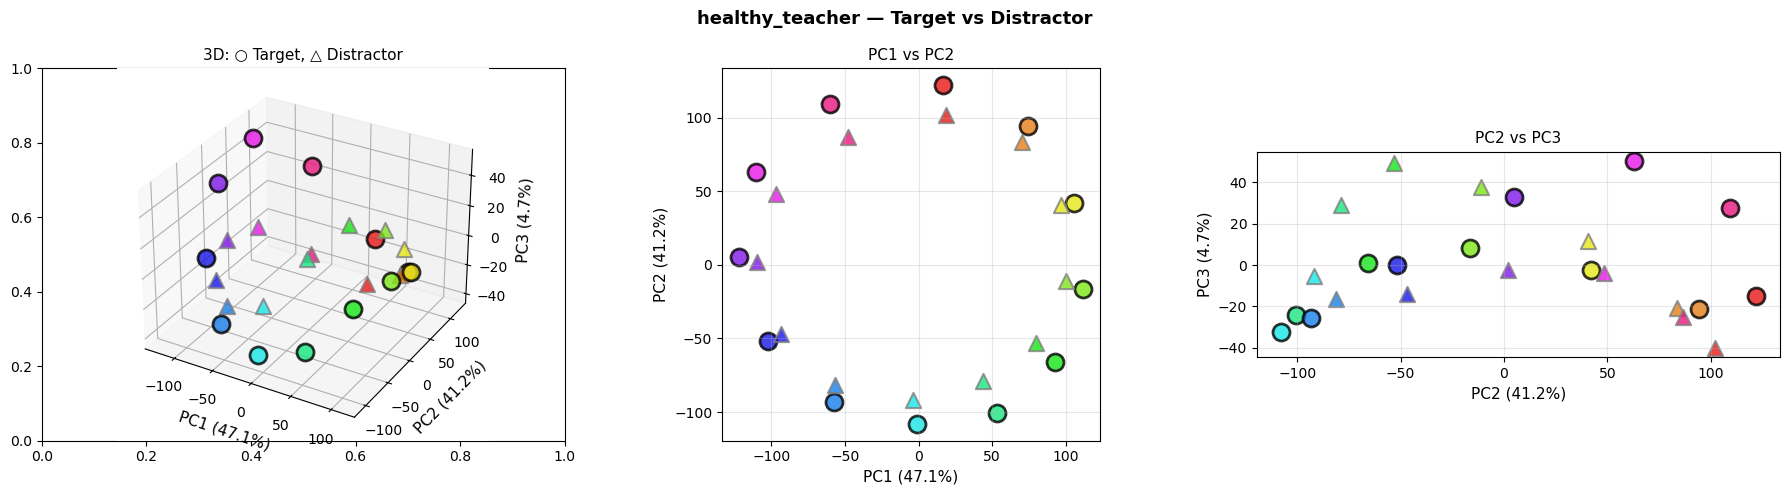

2/4  Prep epoch analysis …
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE 

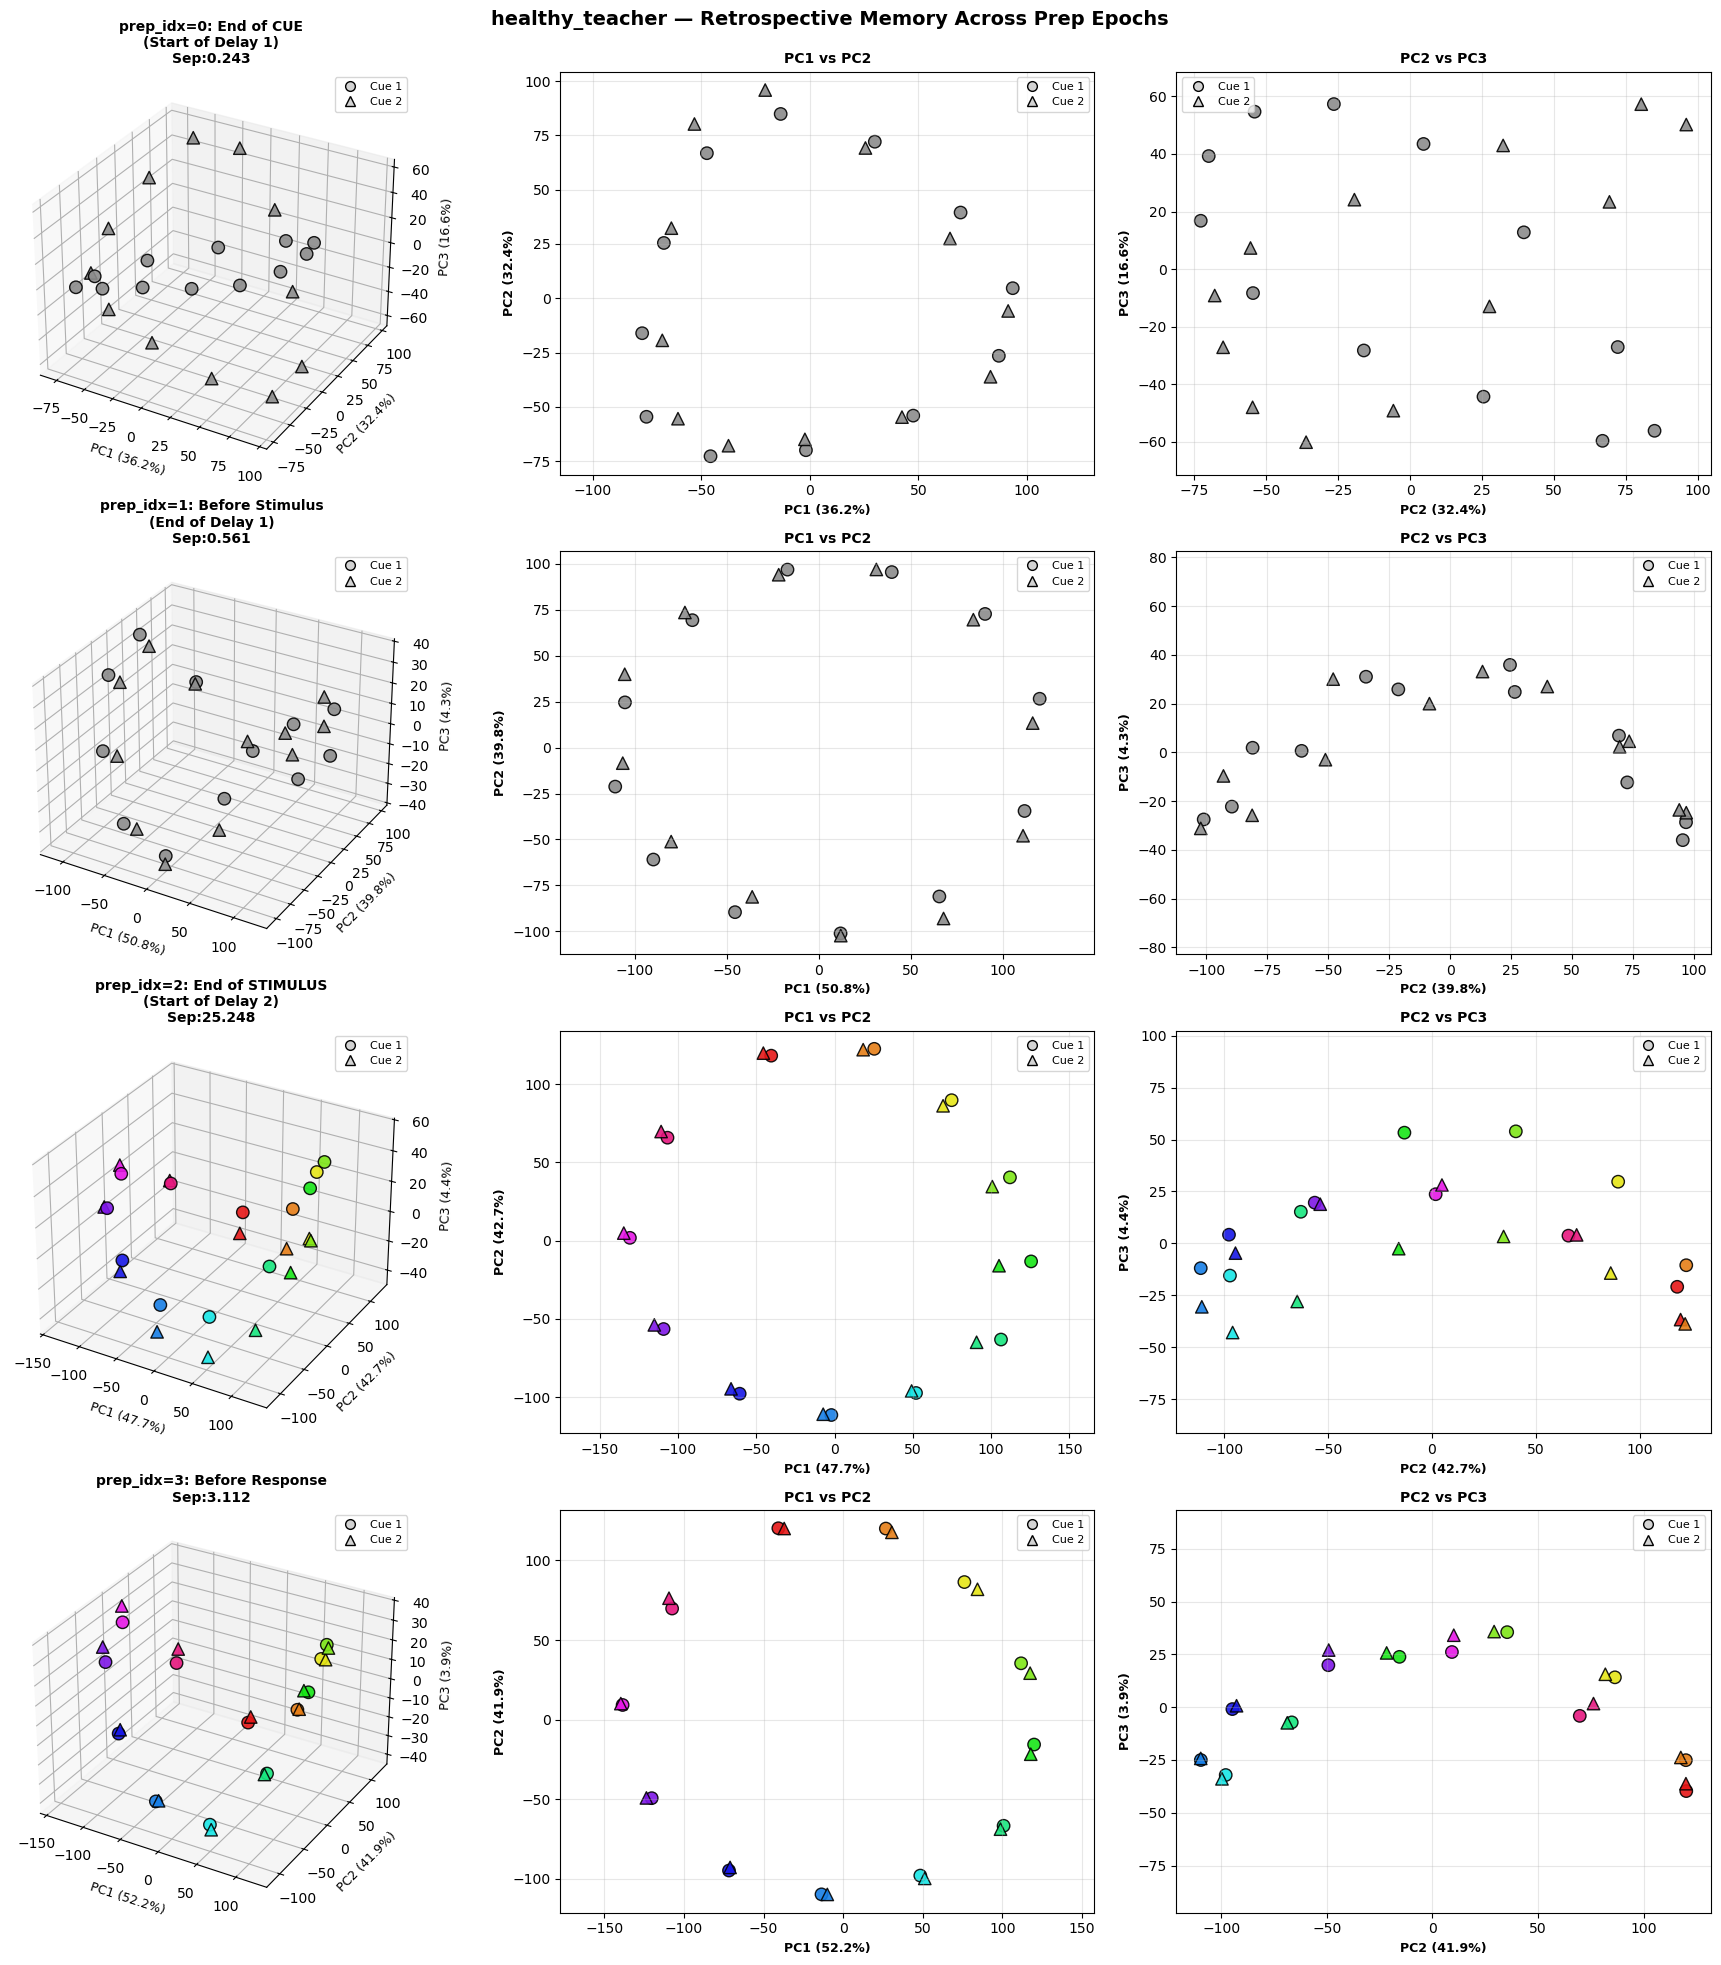

  Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher/retrospective_memory_all_prep_indices.png
3/4  Full timeline extraction …
  trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED 

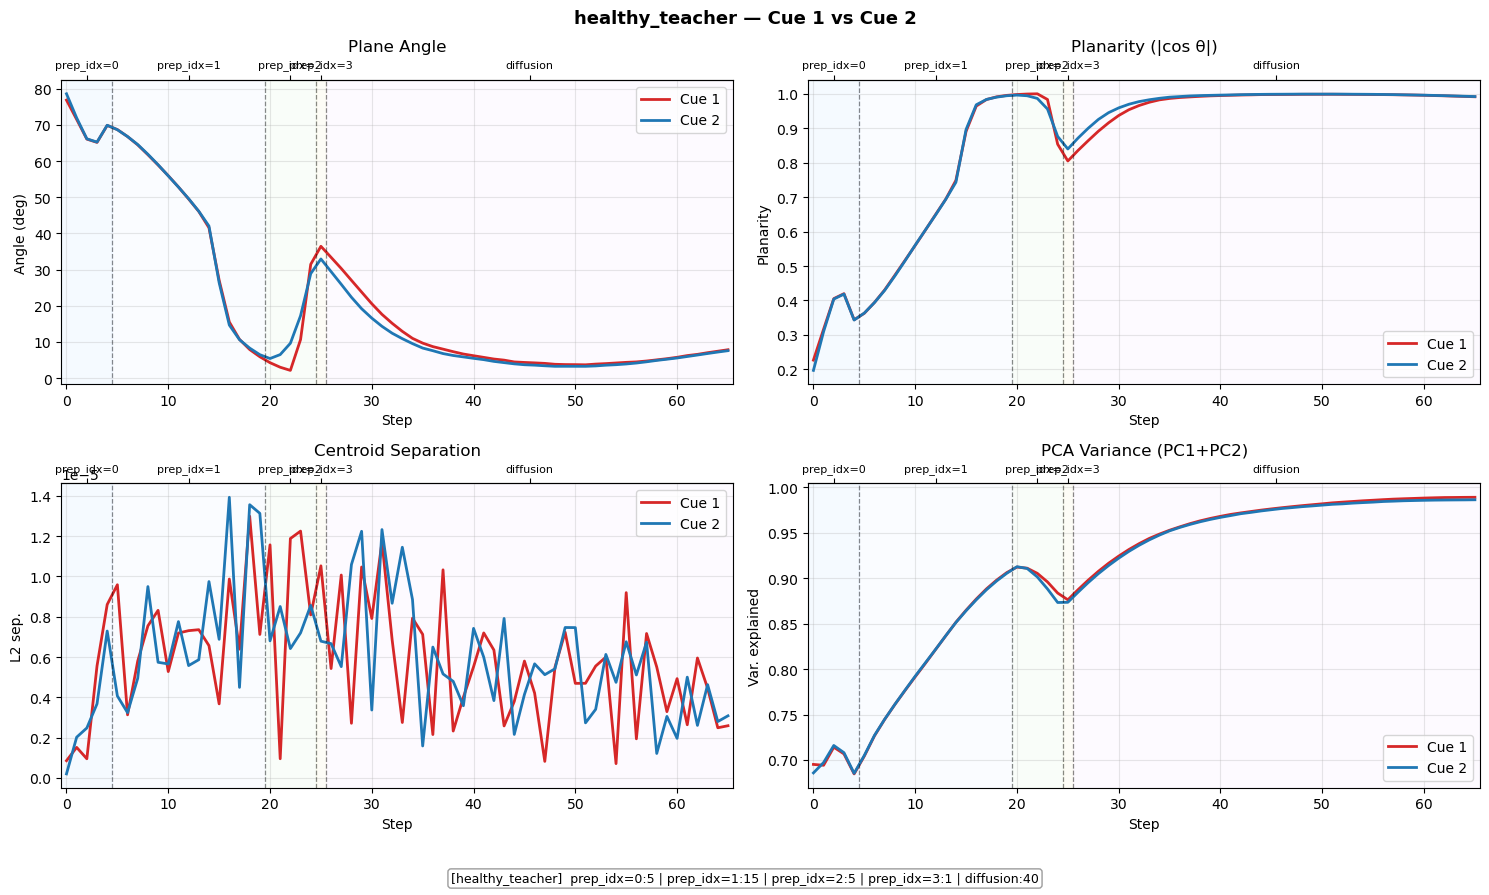

  Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher/timeline_stats_cue1_vs_cue2.png
Active run: student_recovery_8
  Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/student_recovery_8
  Ablation: none

════════════════════════════════════════════════════════════════════════
FULL ANALYSIS: student_recovery_8
════════════════════════════════════════════════════════════════════════
1/4  PCA visualization (target vs distractor) …


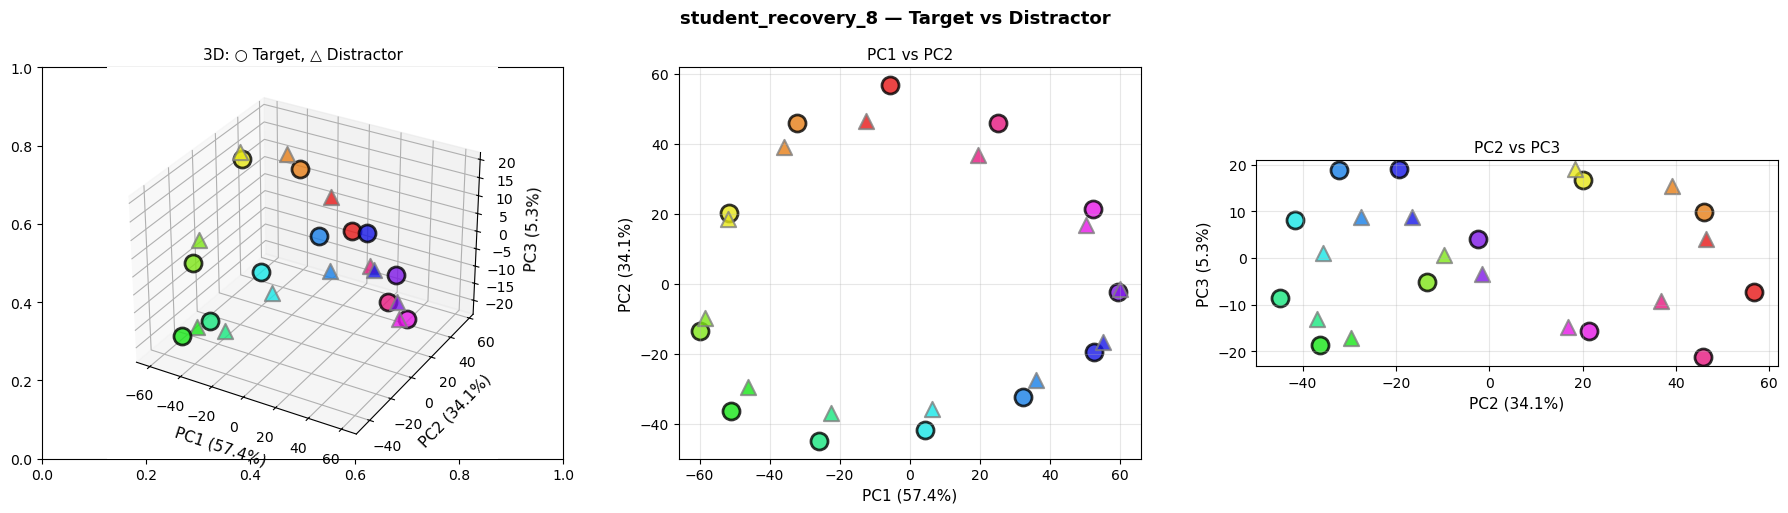

2/4  Prep epoch analysis …
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE 

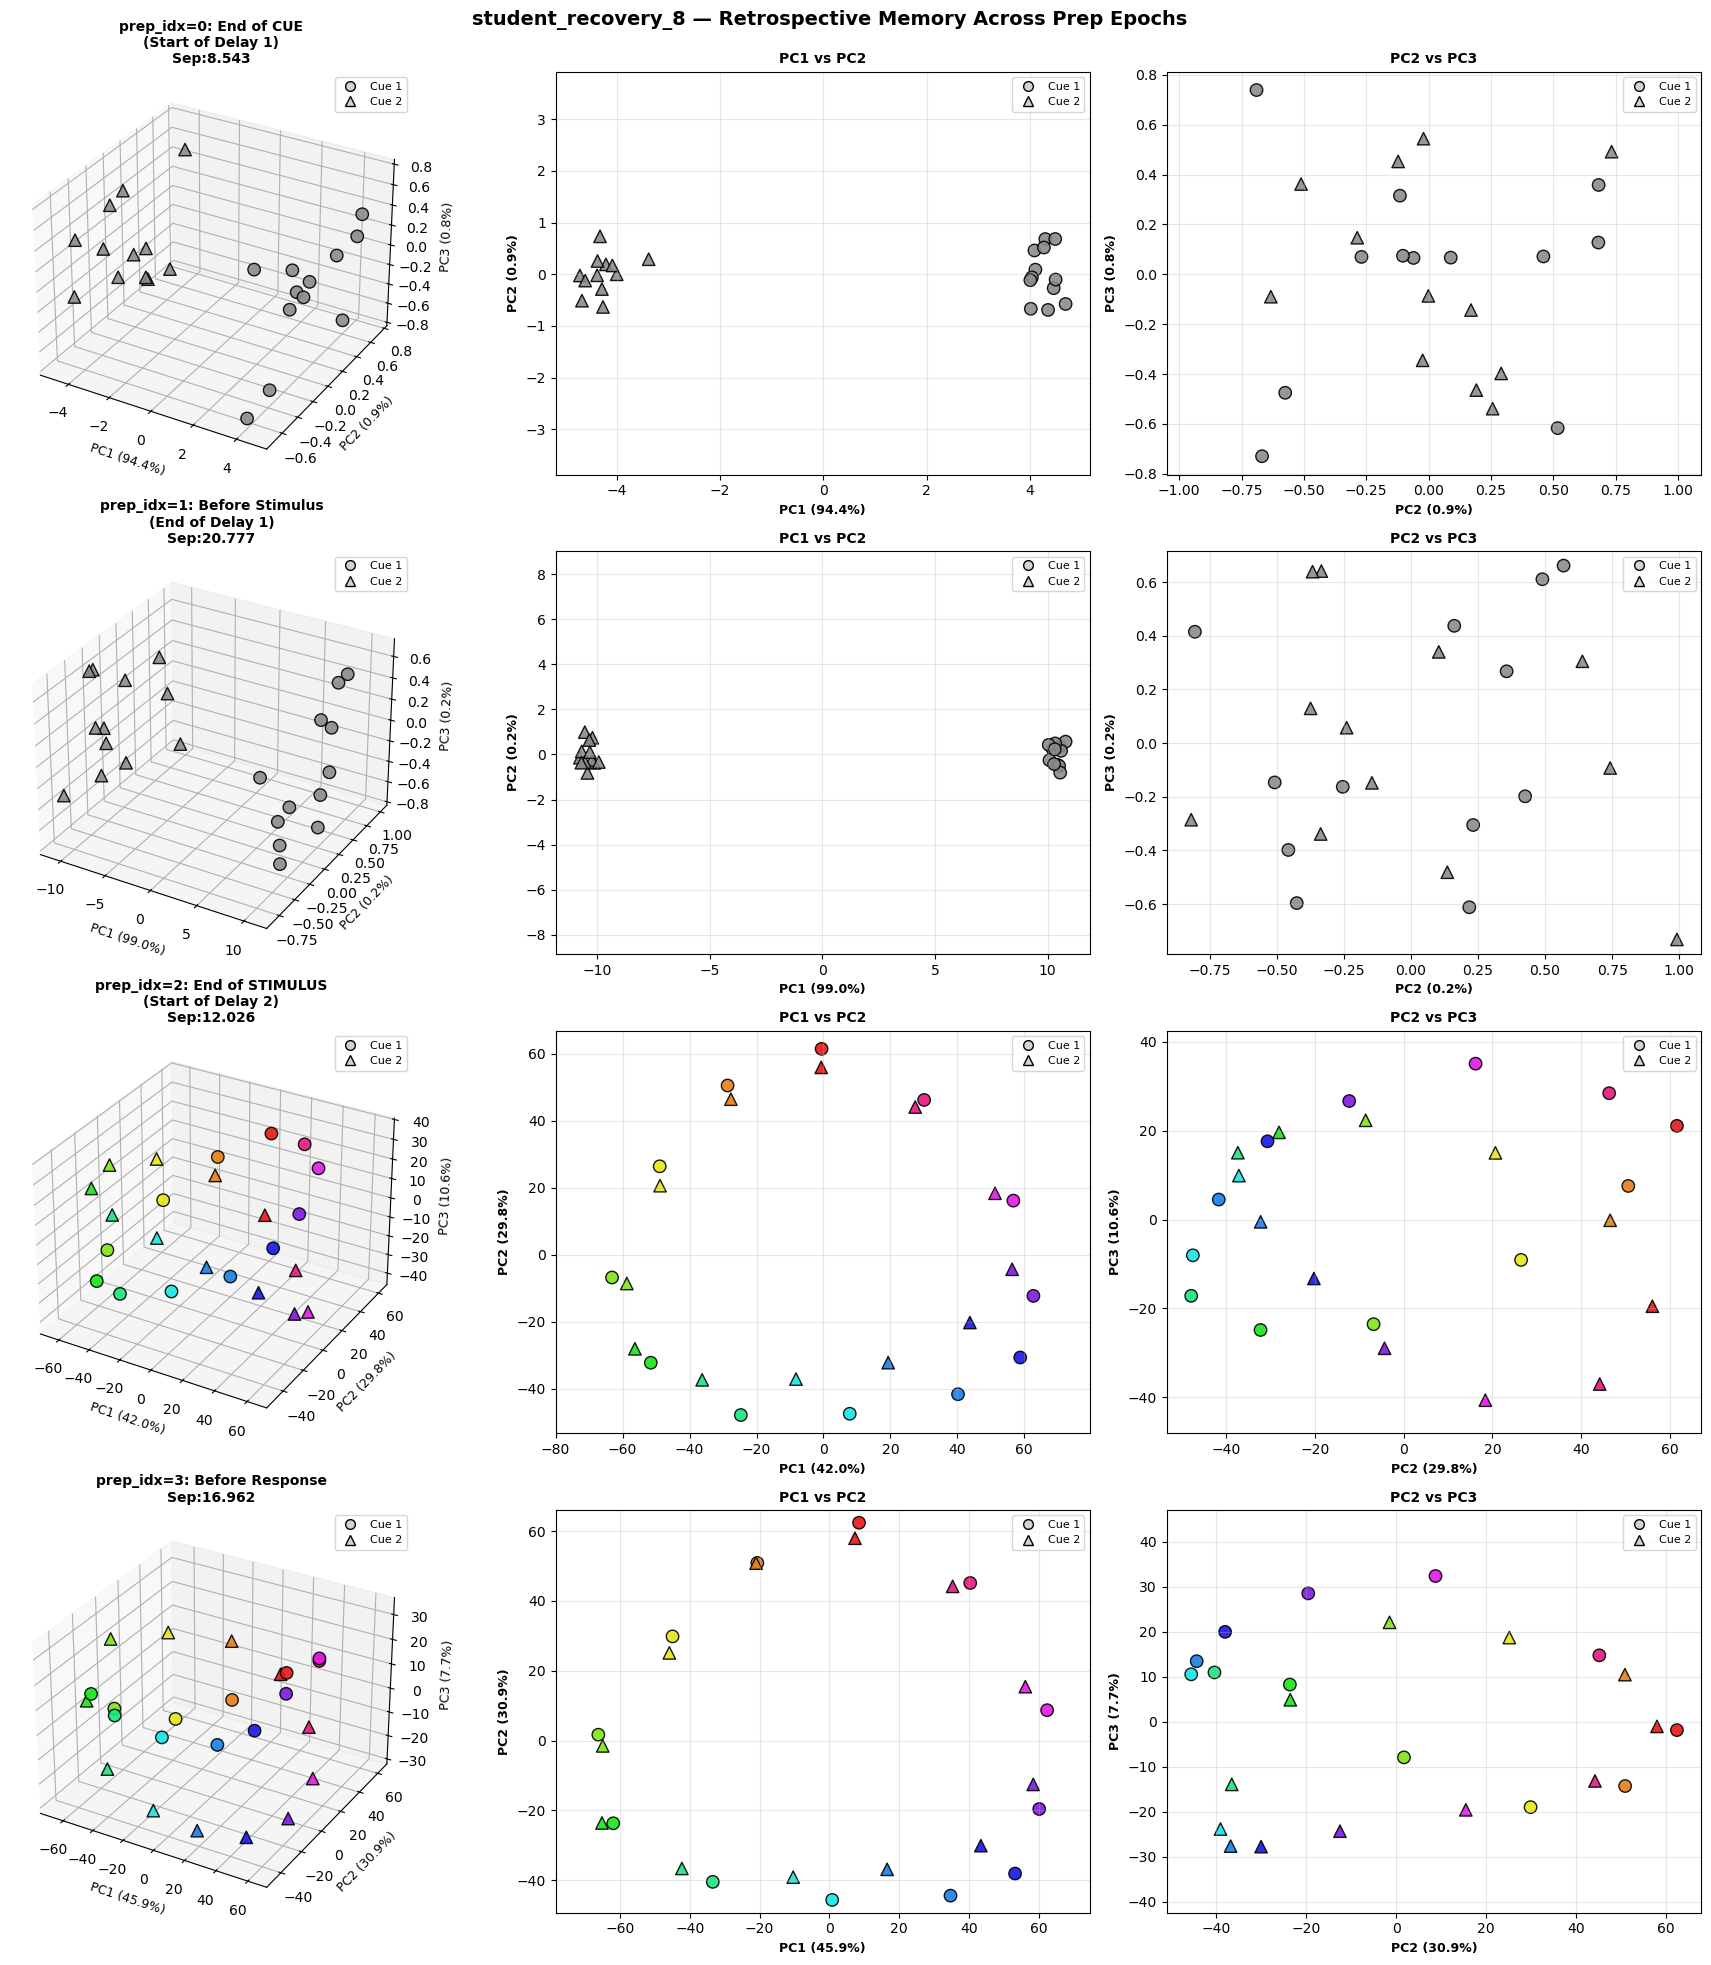

  Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/student_recovery_8/retrospective_memory_all_prep_indices.png
3/4  Full timeline extraction …
  trial 0/288
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECUED ITEMS - SHOULD NEVER BE DONE IN TRAINING
USING PRECU

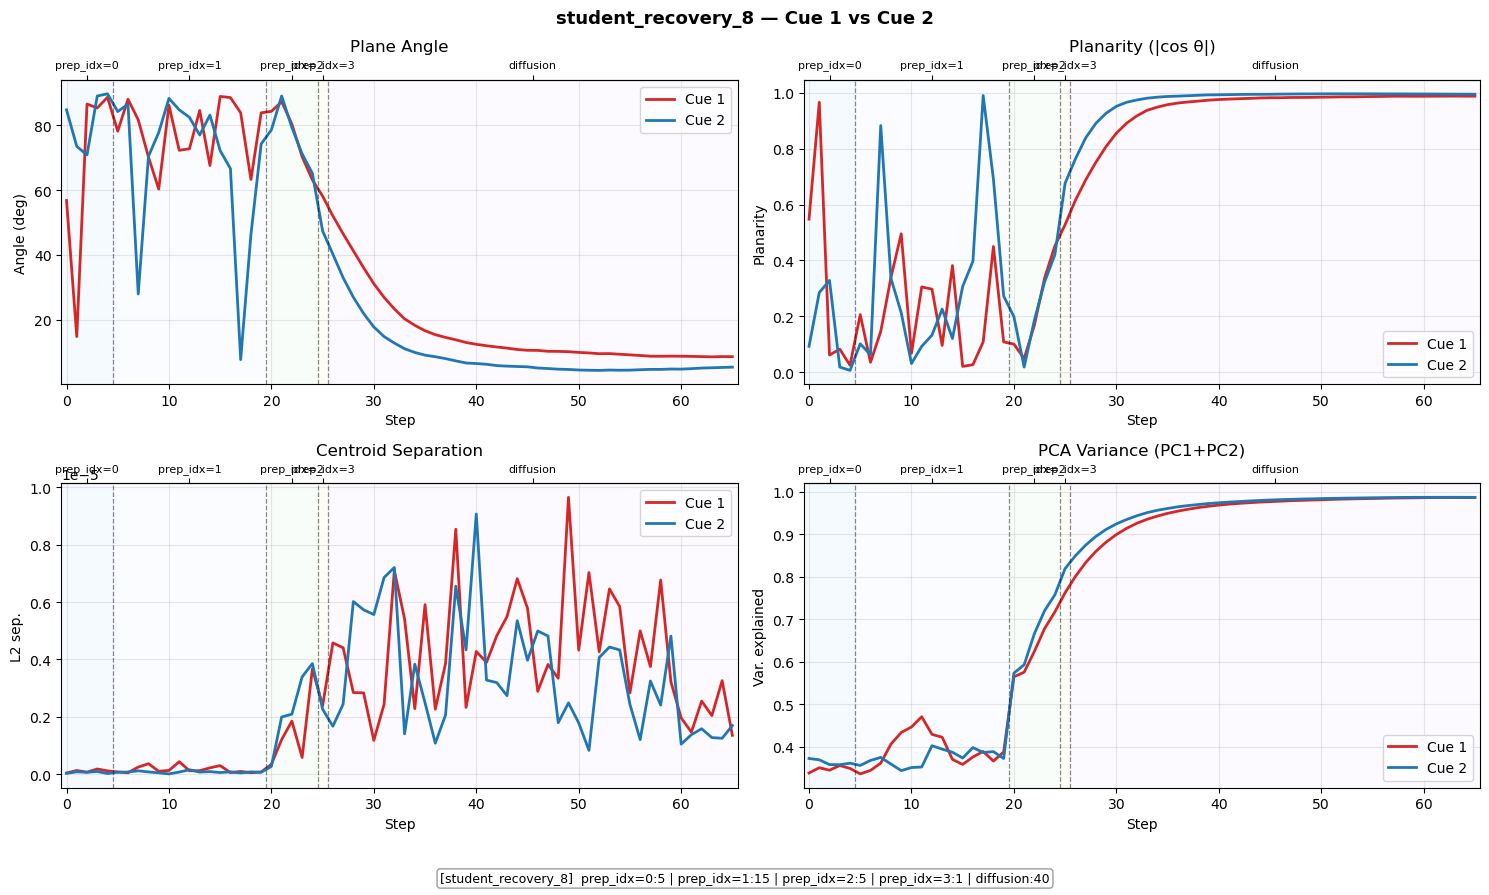

  Saved: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/student_recovery_8/timeline_stats_cue1_vs_cue2.png

All done. Plots written to:
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher
  /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/retrospective_memory_dual/student_recovery_8


In [9]:

# ── Run full analysis for BOTH models ────────────────────────────────────────
for _run in ANALYSIS_RUN_ORDER:
    activate_run(_run, restore_extracted=True)
    run_full_analysis_for_active_run()

print("\nAll done. Plots written to:")
for _run in ANALYSIS_RUN_ORDER:
    print(f"  {LOADED_MODELS[_run]['results_dir']}")


In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import torch
from purias_utils.multiitem_working_memory.util.circle_utils import polar2cart
from ddpm.utils.loading import generate_model_and_task_from_args_path_multiepoch
from pathlib import Path

REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
args_path = REPO_ROOT / 'results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/args.yaml'
ckpt_path = REPO_ROOT / 'results_link_sampler/run_c3_index_cued_diffusion_0.3_swap_2/state.mdl'
out_path = REPO_ROOT / 'ddpm/analysis/new_analysis/results/retrospective_memory_dual/healthy_teacher/retrospective_memory_all_prep_indices_3d_only_colored_rings.png'
out_path.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_, task, model, _, _ = generate_model_and_task_from_args_path_multiepoch(str(args_path), device)
ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
model.load_state_dict(ckpt)
model.eval()

angles = list(range(0,360,30))
trials = []
for cue in [1,2]:
    for color1 in angles:
        for color2 in angles:
            trials.append({'cue':cue,'color1_angle':color1,'color2_angle':color2})

def retro_colour(bin_idx, n_bins=12):
    import colorsys
    return colorsys.hsv_to_rgb(bin_idx / n_bins, 0.9, 0.9)

def bin_angle(angle, bin_size=30.0):
    return int(angle // bin_size) % int(360 // bin_size)

def fit_plane_to_data(data):
    center = np.mean(data, axis=0)
    centered = data - center
    pca = PCA(n_components=3)
    pca.fit(centered)
    normal_vector = pca.components_[2]
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    variance = pca.explained_variance_ratio_
    planarity = variance[:2].sum()
    return normal_vector, center, planarity, variance

def angle_between_planes_degrees(n1,n2):
    cos_angle = np.abs(np.dot(n1,n2))
    cos_angle = min(1.0, max(0.0, cos_angle))
    return np.arccos(cos_angle) * 180 / np.pi

def bin_and_average(states, metadata, n_bins=12):
    bin_size = 360.0 / n_bins
    binned = {1:{b:[] for b in range(n_bins)},2:{b:[] for b in range(n_bins)}}
    for i,(cue,c1,c2) in enumerate(metadata):
        cue = int(cue)
        cued = c1 if cue==1 else c2
        idx = bin_angle(cued, bin_size)
        binned[cue][idx].append(states[i])
    avg = {1: np.zeros((n_bins, states.shape[1])), 2: np.zeros((n_bins, states.shape[1]))}
    for cue in [1,2]:
        for b in range(n_bins):
            avg[cue][b] = np.mean(binned[cue][b], axis=0) if binned[cue][b] else np.nan
    return avg

def extract_state(trial, prep_idx=2):
    with torch.no_grad():
        probe_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]], dtype=torch.float32) * (np.pi/180)
        report_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]], dtype=torch.float32) * (np.pi/180)
        override = {
            'probe_features': probe_features,
            'report_features': report_features,
            'probe_features_cart': torch.stack(polar2cart(1.0, probe_features), -1),
            'report_features_cart': torch.stack(polar2cart(1.0, report_features), -1),
            'cued_item_idx': torch.tensor([trial['cue'] - 1]),
        }
        tvd = task.task_variable_gen.generate_variable_dict(batch_size=1, override_stimulus_features_dict=override)
        ti = task.generate_trial_information(batch_size=1, num_samples=1, override_task_variable_information=tvd)
        pni = [x.to(device) if isinstance(x, torch.Tensor) else x for x in ti.prep_network_inputs]
        dni = [x.to(device) if isinstance(x, torch.Tensor) else x for x in ti.diffusion_network_inputs]
        pd, _ = model.generate_samples(prep_network_inputs=pni, diffusion_network_inputs=dni, prep_epoch_durations=ti.prep_epoch_durations, diffusion_epoch_durations=ti.diffusion_epoch_durations, samples_shape=[1,1], noise_scaler=1.0)
        return pd[prep_idx]['postprep_state'][0,0,:16].cpu().numpy().astype(np.float32)

fig = plt.figure(figsize=(10,18))
fig.suptitle('healthy_teacher — Retrospective Colours-First 3D Snapshots', fontsize=14, fontweight='bold')
for row_idx, prep_idx in enumerate([0,1,2,3]):
    states=[]
    meta=[]
    for trial in trials:
        states.append(extract_state(trial, prep_idx=prep_idx))
        meta.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])
    states = np.asarray(states, dtype=np.float32)
    meta = np.asarray(meta, dtype=np.float32)
    avg = bin_and_average(states, meta, 12)
    all_binned = np.vstack([avg[1], avg[2]])
    all_binned = all_binned[~np.isnan(all_binned).any(axis=1)]
    pca = PCA(n_components=3)
    coords = pca.fit_transform(all_binned)
    cue1 = coords[:12]
    cue2 = coords[12:24]
    n1,c1,p1,_ = fit_plane_to_data(cue1)
    n2,c2,p2,_ = fit_plane_to_data(cue2)
    ang = angle_between_planes_degrees(n1,n2)
    sep = np.linalg.norm(c1 - c2)
    colors = np.array([retro_colour(b,12) for b in range(12)])
    ax = fig.add_subplot(4,1,row_idx+1, projection='3d')
    ax.scatter(cue1[:,0], cue1[:,1], cue1[:,2], c=colors, marker='o', s=80, edgecolors='k', linewidths=1.0, alpha=0.9)
    ax.scatter(cue2[:,0], cue2[:,1], cue2[:,2], c=colors, marker='^', s=80, edgecolors='k', linewidths=1.0, alpha=0.9)
    ax.plot(*np.vstack([cue1, cue1[:1]]).T, color='black', linewidth=1.4, alpha=0.8)
    ax.plot(*np.vstack([cue2, cue2[:1]]).T, color='black', linewidth=1.2, linestyle='--', alpha=0.8)
    vr = pca.explained_variance_ratio_
    ax.set_xlabel(f'PC1 ({vr[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({vr[1]:.1%})', fontsize=10)
    ax.set_zlabel(f'PC3 ({vr[2]:.1%})', fontsize=10)
    ax.set_title(f'Angle: {ang:.1f}°', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.view_init(elev=24, azim=-56)

# global legend
handles = [
    Line2D([0],[0], marker='o', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Colour 1'),
    Line2D([0],[0], marker='^', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Colour 2'),
    Line2D([0],[0], color='black', linestyle='-', linewidth=1.4, label='Colour 1 ring'),
    Line2D([0],[0], color='black', linestyle='--', linewidth=1.2, label='Colour 2 ring'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(out_path)


In [ ]:
# ── Batch: all 14 teacher ablation directions + all 14 students ──────────────
# Run this cell to generate timeline66 (and all other) plots for every
# ablation direction and every student.  Each run saves to a unique directory:
#   retrospective_memory_dual/ablated_teacher_dir_NN/
#   retrospective_memory_dual/student_recovery_N/

import gc

_batch_configs = {}
for _dir_idx in range(14):
    _name = f"ablated_teacher_dir_{_dir_idx:02d}"
    _batch_configs[_name] = {
        "args_path": TEACHER_ARGS_PATH,
        "checkpoint_path": TEACHER_CKPT_PATH,
        "nullspace_json_path": NULLSPACE_JSON_PATH,
        "ablation_direction_idx": _dir_idx,
    }
for _sid in range(14):
    _name = f"student_recovery_{_sid}"
    _batch_configs[_name] = {
        "args_path": REPO_ROOT / f"results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_{_sid}/args.yaml",
        "checkpoint_path": REPO_ROOT / f"results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_{_sid}/state.mdl",
        "nullspace_json_path": None,
        "ablation_direction_idx": None,
    }

print(f"Batch: {len(_batch_configs)} runs to process")

for _run_name, _cfg in _batch_configs.items():
    print(f"\n{'='*80}\nBATCH: {_run_name}\n{'='*80}")

    # Load model fresh for this run
    _, _task_r, _model_r, _, _ = generate_model_and_task_from_args_path_multiepoch(
        str(_cfg["args_path"]), device
    )
    _ckpt = torch.load(_cfg["checkpoint_path"], map_location=device, weights_only=True)
    _model_r.load_state_dict(_ckpt)
    _model_r.eval()

    _abl_vec = None
    if _cfg["nullspace_json_path"] is not None:
        _abl_vec = _load_single_nullspace_vector(
            _cfg["nullspace_json_path"], _cfg["ablation_direction_idx"], device
        )

    _results_dir = DATA_DIR / "results" / "retrospective_memory_dual" / _run_name
    _results_dir.mkdir(parents=True, exist_ok=True)

    # Register in LOADED_MODELS so extract_states_for_run can find it
    LOADED_MODELS[_run_name] = {
        "model": _model_r,
        "task": _task_r,
        "ablation_matrix": _abl_vec,
        "results_dir": _results_dir,
    }

    extract_states_for_run(_run_name, prep_idx=PREP_IDX, force=True)
    run_full_analysis_for_active_run()

    # Release GPU memory before loading the next model
    LOADED_MODELS[_run_name]["model"] = None
    del _model_r, _ckpt
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    print(f"\u2713 Complete: {_run_name}  \u2192  {_results_dir}")

print("\n\u2713 All batch runs complete.")


In [ ]:
# Extract states at prep_idx=2 and bin by BOTH target and distractor
print("=
,
BINNING BY TARGET AND DISTRACTOR AT prep_idx=2")
print("=
,
,
,
N_BINS" not in globals():
    N_BINS = 12

def bin_angle(angle, bin_size=30.0):
    """Bin an angle into discrete bins."""
    return int(angle // bin_size) % int(360 // bin_size)

def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    """Bin trials by cued color and average neural states per bin and cue."""
    bin_size = 360.0 / n_bins
    binned_data = {
        1: {b: [] for b in range(n_bins)},
        2: {b: [] for b in range(n_bins)}
    }

    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        cued_angle = c1 if cue == 1 else c2
        bin_idx = bin_angle(cued_angle, bin_size)
        binned_data[cue][bin_idx].append(states[i])

    averaged_data = {
        1: np.zeros((n_bins, states.shape[1])),
        2: np.zeros((n_bins, states.shape[1]))
    }

    for cue in [1, 2]:
        for b in range(n_bins):
            if binned_data[cue][b]:
                averaged_data[cue][b] = np.mean(binned_data[cue][b], axis=0)
            else:
                averaged_data[cue][b] = np.nan

    return averaged_data, binned_data

# First, extract states at prep_idx=2 if PREP_IDX is not already 2
if PREP_IDX != 2:
    print(f"\nExtracting additional states at prep_idx=2 (currently using prep_idx={PREP_IDX})...")
    states_prep2 = []
    metadata_prep2 = []
    
    for i, trial in enumerate(trials):
        if i % 100 == 0 and i > 0:
            print(f"  Processing trial {i}/{len(trials)}")
        try:
            state = extract_neural_state_from_model(trial, task, model, device, prep_idx=2)
            states_prep2.append(state)
            metadata_prep2.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])
        except Exception as e:
            print(f"  Trial {i} failed: {e}")
            break
    
    states_prep2 = np.array(states_prep2)
    metadata_prep2 = np.array(metadata_prep2)
    print(f"✓ Extracted {len(states_prep2)} states at prep_idx=2")
else:
    # Use the already extracted states
    print(f"\nUsing already extracted states at prep_idx={PREP_IDX}")
    states_prep2 = neural_states.copy()
    metadata_prep2 = metadata.copy()

print(f"\nTotal states at prep_idx=2: {len(states_prep2)}")
print(f"Shape: {states_prep2.shape}")

# Create bins for both target and distractor
# For cue=1: target=color1, distractor=color2
# For cue=2: target=color2, distractor=color1

def bin_by_target_and_distractor(states, metadata, n_bins=12):
    """
    Bin trials by both target color and distractor color.
    
    Args:
        states: Neural states array [n_trials, 16]
        metadata: Metadata array [n_trials, 3] with [cue, color1, color2]
        n_bins: Number of angular bins per dimension
        
    Returns:
        Dictionary with binned states per cue
    """
    bin_size = 360.0 / n_bins
    
    # Initialize storage: cue -> (target_bin, distractor_bin) -> [states]
    binned_data = {
        1: {},
        2: {}
    }
    
    # Bin trials
    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        
        # Determine target and distractor based on cue
        if cue == 1:
            target_angle = c1
            distractor_angle = c2
        else:
            target_angle = c2
            distractor_angle = c1
        
        target_bin = bin_angle(target_angle, bin_size)
        distractor_bin = bin_angle(distractor_angle, bin_size)
        
        key = (target_bin, distractor_bin)
        if key not in binned_data[cue]:
            binned_data[cue][key] = []
        binned_data[cue][key].append(states[i])
    
    # Average per bin
    averaged_data = {1: {}, 2: {}}
    bin_counts = {1: {}, 2: {}}
    
    for cue in [1, 2]:
        for key, states_list in binned_data[cue].items():
            if len(states_list) > 0:
                averaged_data[cue][key] = np.mean(states_list, axis=0)
                bin_counts[cue][key] = len(states_list)
    
    return averaged_data, bin_counts

# Bin the data
averaged_2d, bin_counts_2d = bin_by_target_and_distractor(states_prep2, metadata_prep2, N_BINS)

print(f"\nBinned by target × distractor (12 × 12 = 144 bins per cue)")
print(f"Cue 1: {len(averaged_2d[1])} non-empty bins")
print(f"Cue 2: {len(averaged_2d[2])} non-empty bins")

# Show some statistics
for cue in [1, 2]:
    counts = list(bin_counts_2d[cue].values())
    print(f"\nCue {cue} bin occupancy:")
    print(f"  Total bins with data: {len(counts)}")
    print(f"  Trials per bin - mean: {np.mean(counts):.1f}, min: {min(counts)}, max: {max(counts)}")

In [ ]:
# Visualisation of 2D binned data in PCA space
print("\n" + "=
,
VISUALISATION: TARGET vs DISTRACTOR ENCODING (COMBINED)")
print("=
,
,

# 1. Average by TARGET only (marginalizing over distractor and cue)
target_only_averaged = {}

for target_bin in range(N_BINS):
    # Collect all states with this target bin from BOTH cues
    states_for_target = []
    for cue in [1, 2]:
        for (fine_target, fine_distractor), state in averaged_2d[cue].items():
            if fine_target == target_bin:
                states_for_target.append(state)
    
    if len(states_for_target) > 0:
        target_only_averaged[target_bin] = np.mean(states_for_target, axis=0)

print(f"Target-only averaging (30° bins, both cues combined):")
print(f"  Total target bins: {len(target_only_averaged)}")

# 2. Average by DISTRACTOR only (marginalizing over target and cue)
distractor_only_averaged = {}

for distractor_bin in range(N_BINS):
    # Collect all states with this distractor bin from BOTH cues
    states_for_distractor = []
    for cue in [1, 2]:
        for (fine_target, fine_distractor), state in averaged_2d[cue].items():
            if fine_distractor == distractor_bin:
                states_for_distractor.append(state)
    
    if len(states_for_distractor) > 0:
        distractor_only_averaged[distractor_bin] = np.mean(states_for_distractor, axis=0)

print(f"Distractor-only averaging (30° bins, both cues combined):")
print(f"  Total distractor bins: {len(distractor_only_averaged)}")

# Combine target and distractor states for joint PCA
combined_states = []
combined_metadata = []  # (type, bin) where type: 0=target, 1=distractor

# Add target states
for target_bin, state in sorted(target_only_averaged.items()):
    combined_states.append(state)
    combined_metadata.append((0, target_bin))  # 0 = target

# Add distractor states
for distractor_bin, state in sorted(distractor_only_averaged.items()):
    combined_states.append(state)
    combined_metadata.append((1, distractor_bin))  # 1 = distractor

combined_states = np.array(combined_states)
combined_metadata = np.array(combined_metadata)

print(f"\nCombined states shape: {combined_states.shape}")
print(f"  {(combined_metadata[:, 0] == 0).sum()} target bins + {(combined_metadata[:, 0] == 1).sum()} distractor bins")

# Run PCA on combined set
pca_combined = PCA(n_components=3)
combined_pca = pca_combined.fit_transform(combined_states)

print(f"\nPCA on combined target+distractor:")
print(f"  Explained variance: {pca_combined.explained_variance_ratio_}")
print(f"  Cumulative: {pca_combined.explained_variance_ratio_.cumsum()}")

# Split back into target and distractor
target_mask = combined_metadata[:, 0] == 0
distractor_mask = combined_metadata[:, 0] == 1

target_pca_combined = combined_pca[target_mask]
target_bins_combined = combined_metadata[target_mask, 1].astype(int)

distractor_pca_combined = combined_pca[distractor_mask]
distractor_bins_combined = combined_metadata[distractor_mask, 1].astype(int)

print(f"\nFinal PCA projections:")
print(f"  Target: {target_pca_combined.shape}")
print(f"  Distractor: {distractor_pca_combined.shape}")

# Colour mapping (HSV for 12 bins)
def angle_to_colour(bin_idx, n_bins=12):
    """Convert angle bin (0-11) to HSV colour"""
    hue = bin_idx / n_bins
    return colorsys.hsv_to_rgb(hue, 0.9, 0.9)

# Create visualisation - 1 row × 3 columns format
fig = plt.figure(figsize=(18, 5))

target_pca_data = target_pca_combined
target_bins_data = target_bins_combined
distractor_pca_data = distractor_pca_combined
distractor_bins_data = distractor_bins_combined

# Plot 1: 3D view
ax = fig.add_subplot(131, projection='3d')

# Plot TARGET encoding (circles) with colors
for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax.scatter(target_pca_data[i, 0], target_pca_data[i, 1], target_pca_data[i, 2],
              c=[colour], marker='o', s=150, alpha=0.8, 
              edgecolors='k', linewidth=2)

# Plot DISTRACTOR encoding (triangles) with colors
for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax.scatter(distractor_pca_data[i, 0], distractor_pca_data[i, 1], distractor_pca_data[i, 2],
              c=[colour], marker='^', s=120, alpha=0.8,
              edgecolors='grey', linewidth=1.5)

ax.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('3D View\n○ Target, △ Distractor', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: PC1-PC2 view
ax2 = fig.add_subplot(132)

# Plot TARGET and DISTRACTOR with colors
for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax2.scatter(target_pca_data[i, 0], target_pca_data[i, 1],
               c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)

for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax2.scatter(distractor_pca_data[i, 0], distractor_pca_data[i, 1],
               c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)

ax2.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: PC2-PC3 view  
ax3 = fig.add_subplot(133)

for i in range(len(target_pca_data)):
    colour = angle_to_colour(target_bins_data[i], N_COLOR_BINS)
    ax3.scatter(target_pca_data[i, 1], target_pca_data[i, 2],
               c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)

for i in range(len(distractor_pca_data)):
    colour = angle_to_colour(distractor_bins_data[i], N_COLOR_BINS)
    ax3.scatter(distractor_pca_data[i, 1], distractor_pca_data[i, 2],
               c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)

ax3.set_xlabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png'}")
print(f"   Layout: 1 row × 3 columns (3D, PC1-PC2, PC2-PC3)")
print(f"   Using {N_COLOR_BINS} colour bins (30° each)")
print("   Large circles (○) = averaged by target colour (across all distractors and cues)")
print("   Small triangles (△) = averaged by distractor colour (across all targets and cues)")

In [ ]:
# Fit planes to target and distractor data
print("\n" + "=
,
PLANE FITTING: TARGET vs DISTRACTOR")
print("=
,
,
    Fit a best 2D plane to 3D data points using PCA.
    
    Returns:
        normal_vector: Normal vector to the best-fitting plane
        center: Center point of the data
        planarity: Measure of how well data fits a plane (variance ratio)
        variance: Variance along each principal component
    """
    center = np.mean(data, axis=0)
    centered_data = data - center
    
    pca = PCA(n_components=3)
    pca.fit(centered_data)
    
    # Normal vector is the 3rd principal component (least variance)
    normal_vector = pca.components_[2]
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # Planarity: ratio of variance in first 2 PCs to total
    variance = pca.explained_variance_ratio_
    planarity = variance[:2].sum()  # Variance in the plane
    
    return normal_vector, center, planarity, variance

def angle_between_planes_degrees(normal1, normal2):
    """Calculate angle between two planes in degrees."""
    cos_angle = np.abs(np.dot(normal1, normal2))
    cos_angle = min(1.0, max(0.0, cos_angle))  # Numerical stability
    angle = np.arccos(cos_angle) * 180 / np.pi
    return angle

# Fit planes to target and distractor data
print("\nFitting plane to target data...")
target_normal, target_center, target_planarity, target_variance = fit_plane_to_data(target_pca_combined)
print(f"  Normal: {target_normal}")
print(f"  Center: {target_center}")
print(f"  Planarity: {target_planarity:.2%}")
print(f"  Variance per PC: {target_variance}")

print("\nFitting plane to distractor data...")
distractor_normal, distractor_center, distractor_planarity, distractor_variance = fit_plane_to_data(distractor_pca_combined)
print(f"  Normal: {distractor_normal}")
print(f"  Center: {distractor_center}")  
print(f"  Planarity: {distractor_planarity:.2%}")
print(f"  Variance per PC: {distractor_variance}")

# Compute angle between planes
plane_angle = angle_between_planes_degrees(target_normal, distractor_normal)
print(f"\nAngle between planes: {plane_angle:.2f}°")

# Compute separation between centers
separation = np.linalg.norm(target_center - distractor_center)
print(f"Separation between centers: {separation:.4f}")

# Interpretation
if plane_angle < 10:
    interpretation = "Nearly parallel (co-planar)"
elif plane_angle > 80:
    interpretation = "Nearly orthogonal (independent)"
else:
    interpretation = "Oblique (partially shared)"
print(f"Interpretation: {interpretation}")


In [ ]:
# Plane Fitting Analysis Across All Prep Epochs (Colored Binning)
print("\nPLANE FITTING ANALYSIS: ACROSS ALL PREP EPOCHS")

# Create retrospective memory visualization across all prep indices
# 4 rows x 3 columns: (3D, PC1 vs PC2, PC2 vs PC3) for each prep_idx
print("\nCREATING RETROSPECTIVE MEMORY ALL PREP INDICES VISUALIZATION")

# Helper definitions required by full timeline statistics cell
def _average_role_bins_for_cue(states_t, metadata_arr, cue, role, n_bins=12):
    bin_size = 360.0 / n_bins
    cue_mask = metadata_arr[:, 0].astype(int) == cue
    states_cue = states_t[cue_mask]
    meta_cue = metadata_arr[cue_mask]

    bins = {b: [] for b in range(n_bins)}
    for st, (_, c1, c2) in zip(states_cue, meta_cue):
        if cue == 1:
            angle = c1 if role == 'target' else c2
        else:
            angle = c2 if role == 'target' else c1
        b = int(angle // bin_size) % n_bins
        bins[b].append(st)

    out = []
    for b in range(n_bins):
        if bins[b]:
            out.append(np.mean(bins[b], axis=0))

    if not out:
        return np.empty((0, states_t.shape[1]), dtype=np.float32)
    return np.asarray(out, dtype=np.float32)

def _pc12_variance_ratio(x):
    if x.shape[0] < 3:
        return np.nan
    n_components = min(3, x.shape[0], x.shape[1])
    pca_local = PCA(n_components=n_components)
    pca_local.fit(x)
    ratios = pca_local.explained_variance_ratio_
    return float(ratios[: min(2, len(ratios))].sum())

def _compute_timestep_plane_metrics(states_t, metadata_arr, cue, n_bins=12):
    target_avg = _average_role_bins_for_cue(states_t, metadata_arr, cue, role='target', n_bins=n_bins)
    distractor_avg = _average_role_bins_for_cue(states_t, metadata_arr, cue, role='distractor', n_bins=n_bins)

    if target_avg.shape[0] < 3 or distractor_avg.shape[0] < 3:
        return {
            'plane_angle_deg': np.nan,
            'planarity_cos': np.nan,
            'centroid_separation': np.nan,
            'target_var_pc12': np.nan,
            'distractor_var_pc12': np.nan,
            'combined_var_pc12': np.nan,
            'target_planarity': np.nan,
            'distractor_planarity': np.nan,
            'target_centroid_norm': np.nan,
            'distractor_centroid_norm': np.nan,
        }

    combined = np.vstack([target_avg, distractor_avg])
    pca_combined = PCA(n_components=3)
    coords = pca_combined.fit_transform(combined)

    t_n = target_avg.shape[0]
    target_pca = coords[:t_n]
    distractor_pca = coords[t_n:]

    target_normal, target_center, target_planarity, _ = fit_plane_to_data(target_pca)
    distractor_normal, distractor_center, distractor_planarity, _ = fit_plane_to_data(distractor_pca)

    theta_deg = angle_between_planes_degrees(target_normal, distractor_normal)
    planarity_cos = float(np.abs(np.cos(np.deg2rad(theta_deg))))
    centroid_sep = float(np.linalg.norm(target_center - distractor_center))

    return {
        'plane_angle_deg': float(theta_deg),
        'planarity_cos': planarity_cos,
        'centroid_separation': centroid_sep,
        'target_var_pc12': _pc12_variance_ratio(target_avg),
        'distractor_var_pc12': _pc12_variance_ratio(distractor_avg),
        'combined_var_pc12': float(pca_combined.explained_variance_ratio_[:2].sum()),
        'target_planarity': float(target_planarity),
        'distractor_planarity': float(distractor_planarity),
        'target_centroid_norm': float(np.linalg.norm(target_center)),
        'distractor_centroid_norm': float(np.linalg.norm(distractor_center)),
    }

print('Timestep metric helpers are ready.')

# Full timeline plane statistics: prep (all epochs) + diffusion
print('\nFULL TIMELINE PLANE STATISTICS (PREP + DIFFUSION)')

def extract_full_timeline_from_model(trial, task, model, device, ablation_vector=None):
    with torch.no_grad():
        probe_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)
        report_features = torch.tensor([[trial['color1_angle'], trial['color2_angle']]]) * (np.pi / 180)

        override_stimulus_features = {
            'probe_features': probe_features,
            'report_features': report_features,
        }
        override_stimulus_cart_features = {}
        for k in override_stimulus_features.keys():
            override_stimulus_cart_features[f'{k}_cart'] = torch.stack(
                polar2cart(1.0, override_stimulus_features[k]), -1
            )

        override_stimulus_features_dict = {}
        for k, v in override_stimulus_features.items():
            override_stimulus_features_dict[k] = v
        for k, v in override_stimulus_cart_features.items():
            override_stimulus_features_dict[k] = v

        override_stimulus_features_dict['cued_item_idx'] = torch.tensor([trial['cue'] - 1])

        task_variable_dict = task.task_variable_gen.generate_variable_dict(
            batch_size=1,
            override_stimulus_features_dict=override_stimulus_features_dict,
        )

        trial_info = task.generate_trial_information(
            batch_size=1,
            num_samples=1,
            override_task_variable_information=task_variable_dict,
        )

        prep_network_inputs_device = []
        for inp in trial_info.prep_network_inputs:
            prep_network_inputs_device.append(inp.to(device) if isinstance(inp, torch.Tensor) else inp)

        diffusion_network_inputs_device = []
        for inp in trial_info.diffusion_network_inputs:
            diffusion_network_inputs_device.append(inp.to(device) if isinstance(inp, torch.Tensor) else inp)

        sample_kwargs = {
            'prep_network_inputs': prep_network_inputs_device,
            'diffusion_network_inputs': diffusion_network_inputs_device,
            'prep_epoch_durations': trial_info.prep_epoch_durations,
            'diffusion_epoch_durations': trial_info.diffusion_epoch_durations,
            'samples_shape': [1, 1],
            'noise_scaler': 1.0,
        }
        if ablation_vector is not None:
            sample_kwargs['ablation_vector'] = ablation_vector

        prep_dicts, samples_dict = model.generate_samples(**sample_kwargs)

        prep_segments = []
        prep_epoch_lengths = []
        for prep_idx, prep_dict in enumerate(prep_dicts):
            if 'preparatory_trajectory' not in prep_dict:
                raise KeyError(f"preparatory_trajectory missing in prep_dicts[{prep_idx}]")

            prep_traj = prep_dict['preparatory_trajectory'][0, 0, :, :16].detach().cpu().numpy().astype(np.float32)
            prep_segments.append(prep_traj)
            prep_epoch_lengths.append(int(prep_traj.shape[0]))

        prep_timeline = np.concatenate(prep_segments, axis=0)
        traj_key = 'embedded_sample_trajectory' if 'embedded_sample_trajectory' in samples_dict else 'sample_trajectory'
        diffusion_timeline = samples_dict[traj_key][0, 0, :, :16].detach().cpu().numpy().astype(np.float32)

        full_timeline = np.concatenate([prep_timeline, diffusion_timeline], axis=0)
        return full_timeline, prep_epoch_lengths, int(diffusion_timeline.shape[0])

if 'timeline_states_forward' not in globals() or 'timeline_meta_forward' not in globals():
    print('Extracting full prep+diffusion trajectories from forward pass...')
    traj_rows = []
    meta_rows = []
    prep_epoch_lengths_ref = None
    diffusion_steps_ref = None

    for i, trial in enumerate(trials):
        if i % 50 == 0:
            print(f'  Processing trial {i}/{len(trials)}')

        full_timeline_i, prep_epoch_lengths_i, diffusion_steps_i = extract_full_timeline_from_model(
            trial, task, model, device, ablation_vector=ACTIVE_ABLATION_VECTOR
        )

        if prep_epoch_lengths_ref is None:
            prep_epoch_lengths_ref = prep_epoch_lengths_i
            diffusion_steps_ref = diffusion_steps_i
        else:
            if prep_epoch_lengths_i != prep_epoch_lengths_ref:
                raise RuntimeError(
                    f'Prep epoch lengths vary across trials: {prep_epoch_lengths_ref} vs {prep_epoch_lengths_i}'
                )
            if diffusion_steps_i != diffusion_steps_ref:
                raise RuntimeError(
                    f'Diffusion steps vary across trials: {diffusion_steps_ref} vs {diffusion_steps_i}'
                )

        traj_rows.append(full_timeline_i)
        meta_rows.append([trial['cue'], trial['color1_angle'], trial['color2_angle']])

    timeline_states_forward = np.asarray(traj_rows, dtype=np.float32)
    timeline_meta_forward = np.asarray(meta_rows, dtype=np.float32)
    prep_epoch_lengths_forward = prep_epoch_lengths_ref
    diffusion_steps_forward = diffusion_steps_ref

print(f'timeline_states_forward shape: {timeline_states_forward.shape}')
print(f'timeline_meta_forward shape: {timeline_meta_forward.shape}')

PREP_TOTAL_STEPS = int(sum(prep_epoch_lengths_forward))
DIFFUSION_TOTAL_STEPS = int(diffusion_steps_forward)
TOTAL_STEPS = int(timeline_states_forward.shape[1])

if TOTAL_STEPS != PREP_TOTAL_STEPS + DIFFUSION_TOTAL_STEPS:
    raise RuntimeError(
        f'Total steps mismatch: total={TOTAL_STEPS}, prep={PREP_TOTAL_STEPS}, diffusion={DIFFUSION_TOTAL_STEPS}'
    )

print(f'Prep steps total: {PREP_TOTAL_STEPS}')
print(f'Diffusion steps total: {DIFFUSION_TOTAL_STEPS}')
print(f'Full timeline steps: {TOTAL_STEPS}')

phase_names = []
phase_bounds = [0]
cursor = 0
for i, dur in enumerate(prep_epoch_lengths_forward):
    phase_names.append(f'prep_idx={i}')
    cursor += int(dur)
    phase_bounds.append(cursor)
phase_names.append('diffusion')
phase_bounds.append(TOTAL_STEPS)

print('Timeline mapping:')
cursor = 0
for i, dur in enumerate(prep_epoch_lengths_forward):
    start = cursor
    end = cursor + int(dur) - 1
    print(f'  prep_idx={i}: steps {start}..{end} (duration={dur})')
    cursor += int(dur)
print(f'  diffusion: steps {cursor}..{TOTAL_STEPS - 1} (duration={DIFFUSION_TOTAL_STEPS})')

# compute and visualize timeline metrics
